In [8]:
# ===== 라이브러리 불러오기 =====
import os, glob                       # 파일/폴더 다루기
import duckdb                         # 큰 데이터를 SQL로 빠르게 읽는 도구
import pandas as pd                   # 표 데이터 다루기
import numpy as np                    # 숫자 계산
import matplotlib.pyplot as plt       # 그래프

# ===== 그래프 한글 깨짐 방지 (Windows 기본 폰트) =====
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
pd.set_option('display.max_columns', 50)     # 표 출력 시 컬럼 50개까지 보이기

# ===== 경로 설정 (노트북 위치 기준 상대경로) =====
# Colab으로 옮기면 이 세 줄만 바꾸면 됨
RAW  = '../data/raw/epoch_data'                      # 압축 푼 csv 17개가 있는 곳
SNAP = '../data/raw/video_snapshots_260901.csv.gz'   # 스냅샷 원본 (큰 파일)
PROC = '../data/processed'                           # 직접 만든 파일 저장할 곳
os.makedirs(PROC, exist_ok=True)                     # 폴더 없으면 만들기

# ===== 기준일 =====
D = '2026-09-01'                              # 본선 기준일 (예측해야 하는 날짜)
TRAIN_DATES = ['2026-08-11', '2026-08-25']    # train_labels에 있는 기준일 2개

# ===== DuckDB 연결 =====
con = duckdb.connect()                                 # 메모리 위에 DB 하나 열기
con.sql("SET preserve_insertion_order = false")        # 순서 유지 안 함 → 메모리 절약
con.sql("SET memory_limit = '4GB'")                    # 메모리 최대 4GB까지만 사용

print(sorted(os.listdir(RAW)))   # 파일 17개 + MANIFEST.txt 가 보이면 경로 정상

['MANIFEST.txt', 'app_reviews.csv', 'app_snapshots.csv', 'apps.csv', 'channel_snapshots.csv', 'channels.csv', 'game_app_map.csv', 'igdb_game_map.csv', 'igdb_game_snapshots.csv', 'igdb_games.csv', 'review_features.csv', 'sample_submission.csv', 'train_labels.csv', 'video_5d_views.csv', 'video_games.csv', 'video_igdb_games.csv', 'video_topics.csv', 'videos.csv']


In [9]:
# 스냅샷 csv.gz → parquet 변환 

# parquet = 압축된 열 단위 파일 형식. csv.gz보다 훨씬 빠르게 읽힘
SNAP_PQ = f'{PROC}/video_snapshots.parquet'

# 이미 변환해둔 파일이 있으면 건너뜀 (두 번째 실행부터는 바로 끝남)
if not os.path.exists(SNAP_PQ):
    con.sql(f"""
        COPY (
            SELECT * FROM read_csv('{SNAP}', header=true, auto_detect=true)  -- gz를 압축 안 풀고 바로 읽음
        )
        TO '{SNAP_PQ}' (FORMAT parquet, COMPRESSION zstd)                    -- parquet으로 저장
    """)

print(round(os.path.getsize(SNAP_PQ) / 1e6, 1), 'MB')   # 만들어진 파일 크기 확인

161.5 MB


In [10]:
# 모든 테이블 등록 + 행 수 확인

# csv 파일마다 DuckDB "뷰"를 만듦
# 뷰 = 파일을 실제로 메모리에 올리지 않고, 테이블 이름으로 부를 수 있게 해주는 바로가기
tables = []
for p in sorted(glob.glob(f'{RAW}/*.csv')):
    name = os.path.splitext(os.path.basename(p))[0]      # 'videos.csv' → 'videos'
    con.sql(f"""CREATE OR REPLACE VIEW {name} AS
                SELECT * FROM read_csv('{p}', header=true, auto_detect=true)""")
    tables.append(name)

# 스냅샷은 parquet으로 등록
con.sql(f"CREATE OR REPLACE VIEW video_snapshots AS SELECT * FROM '{SNAP_PQ}'")
tables.append('video_snapshots')

# 테이블별 행 수, 컬럼 이름:타입 정리
rows = []
for t in tables:
    n = con.sql(f"SELECT COUNT(*) FROM {t}").fetchone()[0]   # 행 수
    cols = con.sql(f"DESCRIBE {t}").df()                       # 컬럼 정보
    rows.append({
        'table': t,
        'rows': n,
        'n_cols': len(cols),
        'columns': ', '.join(cols.column_name + ':' + cols.column_type),
    })

overview = pd.DataFrame(rows).sort_values('rows', ascending=False)
overview   # MANIFEST 행 수와 같아야 함 (video_snapshots = 18,051,339)

,table,rows,n_cols,columns
17,video_snapshots,18051339,7,"video_id:VARCHAR, channel_id:VARCHAR, collecte..."
0,app_reviews,148157,16,"recommendation_id:BIGINT, app_id:BIGINT, colle..."
3,channel_snapshots,77177,5,"channel_id:VARCHAR, collected_at:TIMESTAMP, su..."
16,videos,38411,13,"video_id:VARCHAR, channel_id:VARCHAR, publishe..."
12,video_5d_views,31524,10,"video_id:VARCHAR, channel_id:VARCHAR, publishe..."
1,app_snapshots,29262,12,"app_id:BIGINT, collected_at:TIMESTAMP, current..."
15,video_topics,14840,2,"video_id:VARCHAR, topic_category:VARCHAR"
14,video_igdb_games,10386,5,"video_id:VARCHAR, igdb_id:BIGINT, matched_alia..."
9,review_features,2369,9,"app_id:BIGINT, collected_at:TIMESTAMP, num_rev..."
13,video_games,1826,5,"video_id:VARCHAR, app_id:BIGINT, matched_alias..."


모든 행 수가 MANIFEST와 같음. train_labels 컬럼은 row_id, target 두 개.

In [11]:
# 기간 확인 + 누수 체크

# 각 테이블의 날짜 최솟값/최댓값, 그리고 기준일(9/1) 이후 행 수를 확인
# 9/1 이후 행이 있으면 = 정답이 섞여 들어온 것(누수) → 운영진에게 알려야 함
checks = [
    ('videos', 'published_at'),
    ('video_5d_views', 'published_at'),
    ('channel_snapshots', 'collected_at'),
    ('video_snapshots', 'collected_at'),
    ('app_snapshots', 'collected_at'),
    ('igdb_game_snapshots', 'collected_at'),
]

res = []
for t, c in checks:
    mn, mx, leak = con.sql(f"""
        SELECT MIN({c}), MAX({c}),
               COUNT(*) FILTER (WHERE {c} >= TIMESTAMP '{D}')   -- 9/1 이후 행 수
        FROM {t}
    """).fetchone()
    res.append({'table': t, 'col': c, 'min': mn, 'max': mx, 'D 이후 행(0이어야 정상)': leak})

pd.DataFrame(res)

,table,col,min,max,D 이후 행(0이어야 정상)
0,videos,published_at,2026-07-01 07:58:41,2026-08-31 23:59:27,0
1,video_5d_views,published_at,2026-07-10 08:39:51,2026-08-31 23:59:27,0
2,channel_snapshots,collected_at,2026-07-08 13:38:13,2026-08-31 21:00:03,0
3,video_snapshots,collected_at,2026-07-15 08:34:38,2026-08-31 23:45:54,0
4,app_snapshots,collected_at,2026-08-03 07:34:20,2026-08-31 23:02:29,0
5,igdb_game_snapshots,collected_at,2026-08-17 10:49:01,2026-08-31 05:00:01,0


9/1 이후 데이터는 전부 0이다. 

다만 video_5d_views에 8/31 23:59에 올라온 영상이 있음.. view_5d는 업로드 후 108시간(4.5일)이 지나야 생기는 값이라서, 8/27 12시 이후 영상은 값이 비어 있어야 하기 때문에 추가 확인 필요. 

=>

In [12]:
# train_labels 열어보기 

# 학습용 정답 파일 내용 확인
tl = con.sql("SELECT * FROM train_labels").df()
print(tl.shape)      # (행 수, 컬럼 수) → 1,267행이어야 함
print(tl.dtypes)     # 컬럼 이름과 타입
tl.head()            # 앞 5줄

(1267, 2)
row_id      str
target    int64
dtype: object


,row_id,target
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-08-11,0
1,UCnkytUgy0CtWd06up9CjNxg_2026-08-11,0
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-08-11,0
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-08-11,0
4,UCSzHok6X5qXEO7cjvVnE62g_2026-08-11,0


In [13]:
# 기준일별 라벨 구조 

# 컬럼 이름을 아직 몰라서 자동으로 찾음 (틀리면 아래 두 변수를 직접 지정)
date_col  = next((c for c in tl.columns if any(k in c.lower() for k in ['date', 'ref', '기준'])), None)
label_col = next((c for c in tl.columns if c.lower() in ['label', 'target', 'y', 'is_rising']), None)

# channel_id 컬럼이 없으면 row_id("채널ID_날짜")에서 잘라서 만듦
if 'channel_id' not in tl.columns and 'row_id' in tl.columns:
    tl['channel_id'] = tl['row_id'].str.rsplit('_', n=1).str[0]
# 기준일 컬럼이 없으면 row_id 뒷부분에서 만듦
if date_col is None and 'row_id' in tl.columns:
    tl['ref_date'] = tl['row_id'].str.rsplit('_', n=1).str[1]
    date_col = 'ref_date'

print('기준일 컬럼:', date_col, '| 라벨 컬럼:', label_col)

# 기준일별 행 수와 양성(label=1) 비율 → 비율은 0.2 근처여야 함
display(tl.groupby(date_col).agg(n=('channel_id', 'size'), pos_rate=(label_col, 'mean')))

# 두 기준일에 같은 채널이 얼마나 겹치는지
s = {d: set(g.channel_id) for d, g in tl.groupby(date_col)}
d1, d2 = sorted(s)[:2]
print(f'공통 채널: {len(s[d1] & s[d2])} | {d1}에만: {len(s[d1] - s[d2])} | {d2}에만: {len(s[d2] - s[d1])}')

# 공통 채널 중 두 날짜 라벨이 같은 비율
# 높으면 → "뜨는 채널은 계속 뜬다", 낮으면 → "매번 다른 채널이 뜬다(평균 회귀)"
both = tl[tl.channel_id.isin(s[d1] & s[d2])].pivot_table(index='channel_id', columns=date_col, values=label_col)
print('두 기준일 라벨 일치율:', round((both[d1] == both[d2]).mean(), 3))

기준일 컬럼: ref_date | 라벨 컬럼: target


,n,pos_rate
ref_date,,
2026-08-11,601,0.201331
2026-08-25,666,0.201201


공통 채널: 600 | 2026-08-11에만: 1 | 2026-08-25에만: 66
두 기준일 라벨 일치율: 0.738


- 양성 비율이 0.201 (문서와 동일)

- 두 기준일 라벨 일치율은 0.738 (아무 관계가 없어도 일치율이 0.68은 나온다(둘 다 0일 확률 0.8×0.8 + 둘 다 1일 확률 0.2×0.2). 즉 8/11에 뜬 채널이 8/25에도 뜨는 경향은 약한편으로 해석 가능함)


In [14]:
# sample_submission (채점 대상 694개) 

ss = con.sql("SELECT * FROM sample_submission").df()
ss['channel_id'] = ss['row_id'].str.rsplit('_', n=1).str[0]     # row_id에서 채널 ID만 떼기

print(len(ss))                                                   # 694여야 함
print(ss['row_id'].str.rsplit('_', n=1).str[1].unique())         # 기준일 → 2026-09-01 하나여야 함

# 채점 대상 채널이 전부 channels 테이블에 있는지
all_ch = set(con.sql("SELECT channel_id FROM channels").df().channel_id)
print('channels에 없는 채널:', len(set(ss.channel_id) - all_ch))  # 0이어야 정상

# 채점 대상 채널 중 train_labels에도 나오는 채널 수
for d in s:
    print(f'train_labels({d})에도 있는 채널: {len(set(ss.channel_id) & s[d])} / 694')

694
['2026-09-01']
channels에 없는 채널: 0
train_labels(2026-08-11)에도 있는 채널: 600 / 694
train_labels(2026-08-25)에도 있는 채널: 666 / 694


In [15]:
# view_5d 결측과 쇼츠·롱폼 차이 

# videos(전체 영상)에 video_5d_views를 붙여서, 5일 조회수가 있는 영상 비율 확인
con.sql("""
SELECT v.is_shorts,                                          -- 0=롱폼, 1=쇼츠
       COUNT(*)                                  AS n_videos,     -- 전체 영상 수
       COUNT(f.view_5d)                          AS n_with_5d,    -- view_5d 있는 영상 수
       ROUND(1 - COUNT(f.view_5d) / COUNT(*), 3) AS missing_rate, -- 결측률 (약 0.25 예상)
       MEDIAN(f.view_5d)                         AS med_view_5d,  -- 5일 조회수 중앙값
       MEDIAN(f.max_gap)                         AS med_max_gap   -- 구간 내 스냅샷 개수 중앙값
FROM videos v
LEFT JOIN video_5d_views f USING (video_id)                  -- view_5d 없는 영상도 남기기
GROUP BY v.is_shorts
""").df()

,is_shorts,n_videos,n_with_5d,missing_rate,med_view_5d,med_max_gap
0,1,11670,9858,0.155,31935.0,0.01
1,0,26741,21666,0.190,8289.5,0.02


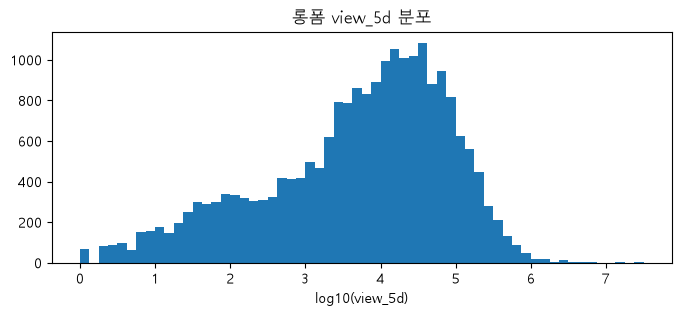

In [16]:
# 롱폼 view_5d 분포 

# 조회수는 편차가 커서 log10으로 보면 분포가 잘 보임 (3 = 1,000회, 5 = 10만회)
x = con.sql("SELECT view_5d FROM video_5d_views WHERE is_shorts = 0 AND view_5d > 0").df().view_5d
plt.figure(figsize=(8, 3))
plt.hist(np.log10(x), bins=60)
plt.xlabel('log10(view_5d)')
plt.title('롱폼 view_5d 분포')
plt.show()

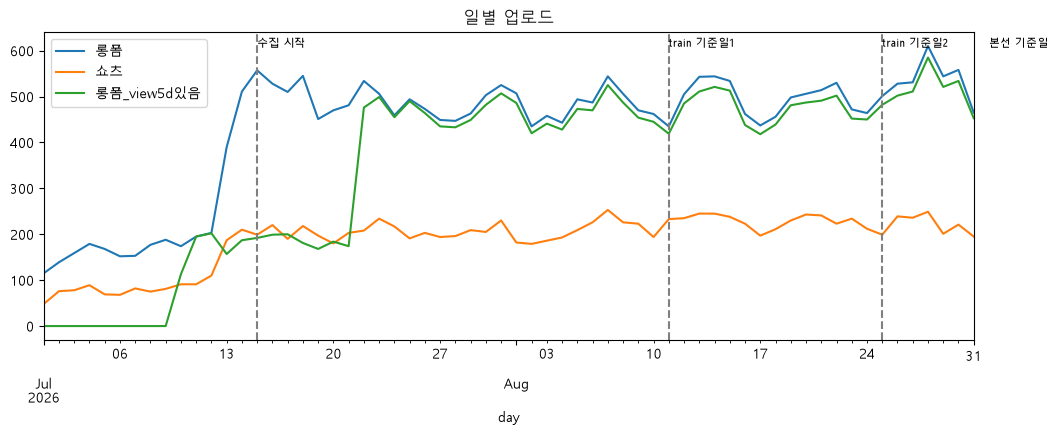

In [17]:
# 일별 업로드 추이

# 하루마다 롱폼/쇼츠 업로드 수, 그중 view_5d가 있는 롱폼 수
# 기준일 직전 5.5일은 view_5d가 없어야 정상 (아직 5일이 안 지났으니까)
daily = con.sql("""
SELECT CAST(v.published_at AS DATE)                       AS day,
       COUNT(*) FILTER (WHERE v.is_shorts = 0)            AS 롱폼,
       COUNT(*) FILTER (WHERE v.is_shorts = 1)            AS 쇼츠,
       COUNT(f.view_5d) FILTER (WHERE v.is_shorts = 0)    AS 롱폼_view5d있음
FROM videos v
LEFT JOIN video_5d_views f USING (video_id)
WHERE v.published_at >= TIMESTAMP '2026-06-15'
GROUP BY 1
ORDER BY 1
""").df()

ax = daily.plot(x='day', figsize=(12, 4))
# 중요한 날짜에 점선 표시
for d, lab in [('2026-07-15', '수집 시작'), ('2026-08-11', 'train 기준일1'),
               ('2026-08-25', 'train 기준일2'), (D, '본선 기준일')]:
    ax.axvline(pd.Timestamp(d), ls='--', c='gray')
    ax.text(pd.Timestamp(d), ax.get_ylim()[1] * 0.95, lab, fontsize=8)
plt.title('일별 업로드')
plt.show()

In [18]:
# 표본 조건 재현

# 문서 규칙: 기준일 이전 롱폼 영상 중 view_5d 있는 것 3편 이상 & 그 중앙값(past_score) 100 이상
def channel_past(Dref):
    """기준일 Dref 이전 롱폼 영상으로 채널별 영상 수와 past_score 계산"""
    return con.sql(f"""
        SELECT channel_id,
               COUNT(*)        AS n_long_5d,     -- view_5d 있는 롱폼 영상 수
               MEDIAN(view_5d) AS past_score     -- 라벨 계산에 쓰는 과거 점수
        FROM video_5d_views
        WHERE is_shorts = 0
          AND view_5d IS NOT NULL
          AND published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    """).df()

for Dref in TRAIN_DATES + [D]:
    cp = channel_past(Dref)
    ok = cp[(cp.n_long_5d >= 3) & (cp.past_score >= 100)]
    print(f'{Dref}: 조건 만족 채널 {len(ok)}')

# 이 숫자가 train_labels 기준일별 행 수, 그리고 694와 비슷하면 규칙을 제대로 이해한 것

2026-08-11: 조건 만족 채널 596
2026-08-25: 조건 만족 채널 662
2026-09-01: 조건 만족 채널 688


미세하게 다름 추가 확인 필요

,n_snap,first_seen,last_seen,subs
count,1868.000000,1868,1868,1.868000e+03
mean,41.315310,2026-07-31 06:23:58.971092,2026-08-31 20:12:24.268736,1.692437e+05
min,1.000000,2026-07-08 13:38:13,2026-07-08 13:38:13,0.000000e+00
25%,41.000000,2026-07-08 13:38:13,2026-08-31 21:00:03,3.800000e+01
50%,41.000000,2026-08-12 05:42:11,2026-08-31 21:00:03,5.460000e+03
75%,42.000000,2026-08-12 05:42:11,2026-08-31 21:00:03,6.740000e+04
max,42.000000,2026-08-12 05:42:11,2026-08-31 21:00:03,3.550000e+07
std,1.105879,NaN,NaN,1.178362e+06


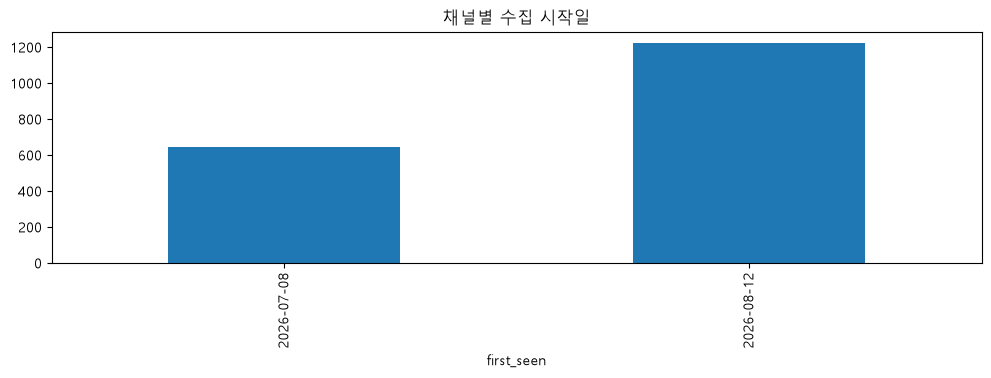

In [19]:
# 채널 스냅샷 (구독자 이력) 

# 채널마다 스냅샷이 몇 개인지, 언제부터 수집됐는지
cs = con.sql("""
SELECT channel_id,
       COUNT(*)              AS n_snap,       -- 스냅샷 개수 (하루 2회 수집)
       MIN(collected_at)     AS first_seen,   -- 수집 시작 시점
       MAX(collected_at)     AS last_seen,    -- 마지막 수집 시점
       MAX(subscriber_count) AS subs          -- 최대 구독자 수
FROM channel_snapshots
GROUP BY 1
""").df()
display(cs.describe())

# 채널별 수집 시작일 분포 → 채널마다 이력 길이가 다르다는 걸 확인
cs['first_seen'].dt.date.value_counts().sort_index().plot(kind='bar', figsize=(12, 3), title='채널별 수집 시작일')
plt.show()

In [20]:
# 영상 스냅샷 전체 요약 

con.sql("""
SELECT COUNT(DISTINCT video_id)            AS n_videos,         -- 영상 수
       COUNT(*) / COUNT(DISTINCT video_id) AS snaps_per_video,  -- 영상 1개당 평균 스냅샷 수
       MEDIAN(video_age_hours)             AS med_age_h,        -- 스냅샷 시점 영상 나이 중앙값(시간)
       MAX(video_age_hours)                AS max_age_h
FROM video_snapshots
""").df()

,n_videos,snaps_per_video,med_age_h,max_age_h
0,37821,477.283493,93.0,720.0


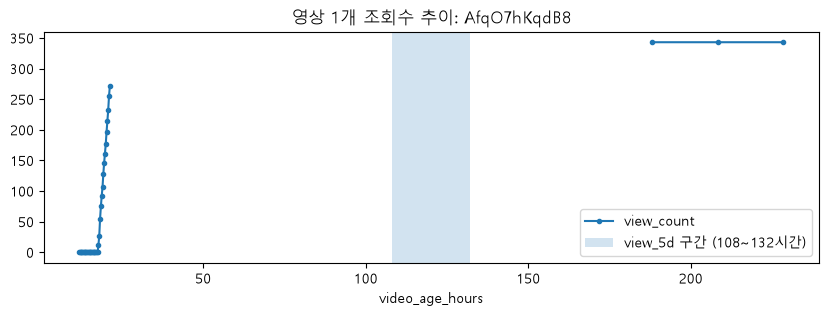

,collected_at,video_age_hours,view_count
0,2026-08-07 03:15:22,11.80,0
1,2026-08-07 03:30:21,12.05,0
2,2026-08-07 03:45:21,12.30,0
3,2026-08-07 04:00:21,12.55,0
4,2026-08-07 04:15:20,12.80,0
5,2026-08-07 04:30:21,13.05,0
6,2026-08-07 04:45:22,13.30,0
7,2026-08-07 05:00:20,13.55,0
8,2026-08-07 05:15:21,13.80,0
9,2026-08-07 05:30:20,14.05,0


In [21]:
# 영상 1개의 조회수 추이

# 구간 안 스냅샷이 3개 이상인 롱폼 영상 하나를 골라서 조회수 변화를 그려봄
vid = con.sql("SELECT video_id FROM video_5d_views WHERE is_shorts = 0 AND max_gap >= 3 LIMIT 1").fetchone()[0]

sn = con.sql(f"""
    SELECT collected_at, video_age_hours, view_count
    FROM video_snapshots
    WHERE video_id = '{vid}'
    ORDER BY collected_at
""").df()

sn.plot(x='video_age_hours', y='view_count', marker='.', figsize=(10, 3), title=f'영상 1개 조회수 추이: {vid}')
plt.axvspan(108, 132, alpha=0.2, label='view_5d 구간 (108~132시간)')   # 라벨에 쓰는 구간 표시
plt.legend()
plt.show()
sn.head(15)

In [22]:
# 기준일 직전 영상의 view_5d 확인 (누수 체크) 

# 9/1 0시 기준으로 108시간(4.5일)이 안 지난 영상 = 8/27 12시 이후 업로드
# 이 영상들은 view_5d가 비어 있어야 정상
con.sql("""
SELECT COUNT(*)        AS 행_수,
       COUNT(view_5d)  AS view_5d_있는_행,    -- 0이어야 정상
       MAX(h_after)    AS 가장_늦은_스냅샷_나이  -- 있다면 몇 시간째 값인지
FROM video_5d_views
WHERE published_at >= TIMESTAMP '2026-08-27 12:00:00'
""").df()

,행_수,view_5d_있는_행,가장_늦은_스냅샷_나이
0,3269,3269,228.75


In [23]:
# 8/27 12시 이후 업로드 영상: view_5d vs 배포된 스냅샷 중 마지막 조회수 비교
cmp = con.sql("""
WITH last_snap AS (
    -- 영상별로 배포된 스냅샷 중 가장 마지막 것의 조회수와 나이
    SELECT video_id,
           arg_max(view_count, collected_at)  AS 마지막_조회수,
           MAX(video_age_hours)               AS 마지막_나이
    FROM video_snapshots
    GROUP BY video_id
)
SELECT f.video_id, f.published_at, f.view_5d, f.h_before, f.h_after,
       l.마지막_조회수, l.마지막_나이
FROM video_5d_views f
JOIN last_snap l USING (video_id)
WHERE f.published_at >= TIMESTAMP '2026-08-27 12:00:00'
  AND f.view_5d IS NOT NULL
""").df()

cmp['비율'] = cmp['view_5d'] / cmp['마지막_조회수'].clip(lower=1)   # 1이면 같은 값

print('비교 영상 수:', len(cmp))
print('view_5d == 마지막 조회수 인 비율:', round((cmp['view_5d'] == cmp['마지막_조회수']).mean(), 3))
print(cmp['비율'].describe())       # 1 근처면 "마지막 값으로 채움", 1보다 확연히 크면 "미래 값"
cmp.sample(10, random_state=0)      # 직접 눈으로 몇 개 보기

비교 영상 수: 2697
view_5d == 마지막 조회수 인 비율: 0.027
count     2697.000000
mean        26.782864
std        842.045016
min          0.000000
25%          1.026622
50%          1.077860
75%          1.208731
max      34612.000000
Name: 비율, dtype: float64


,video_id,published_at,view_5d,h_before,h_after,마지막_조회수,마지막_나이,비율
672,Qp2amXumb4g,2026-08-28 11:47:31,81285,119.97,120.22,50061,83.97,1.623719
1548,EVtgfi6rQos,2026-08-29 14:29:17,216,119.77,120.02,181,57.28,1.193370
1185,_uH_y_kXZR4,2026-08-30 12:00:32,12185,119.75,120.01,5834,35.76,2.088618
1859,MLS4gwEV_8M,2026-08-30 08:22:38,47590,119.89,120.14,41031,39.39,1.159855
1535,ilM6cYIikng,2026-08-29 13:37:51,10401,119.88,120.13,8818,58.13,1.179519
581,eOUTc0FketI,2026-08-28 09:15:07,101537,119.76,120.01,98246,86.51,1.033498
1180,mBWIqM4Sb-c,2026-08-30 22:33:23,1810,119.96,120.21,1463,25.21,1.237184
480,4nuSZc8gE0s,2026-08-28 06:51:27,68344,119.90,120.16,64911,88.91,1.052888
2684,HSsebPDtYQQ,2026-08-30 19:00:07,42519,119.76,120.02,24590,28.76,1.729118
1972,l4HLGmrwHCM,2026-08-29 13:59:13,76835,119.78,120.03,69392,57.78,1.107260


In [24]:
# train_labels에 channel_id 컬럼 만들기 (row_id = "채널ID_날짜")
tl['channel_id'] = tl['row_id'].str.rsplit('_', n=1).str[0]

for Dref in TRAIN_DATES:
    cp = channel_past(Dref)                                         # 셀 8에서 만든 함수
    mine = set(cp[(cp.n_long_5d >= 3) & (cp.past_score >= 100)].channel_id)   # 내 계산
    real = set(tl[tl.ref_date == Dref].channel_id)                             # 실제 라벨

    only_real = real - mine     # 라벨에는 있는데 내 계산에서 빠진 채널
    only_mine = mine - real     # 내 계산에만 있는 채널
    print(f'== {Dref}: 라벨에만 {len(only_real)}개 | 내 계산에만 {len(only_mine)}개')

    # 빠진 채널들의 영상 수와 past_score 확인 → 경계값(영상 2편, 점수 99 등)인지 보기
    display(cp[cp.channel_id.isin(only_real)])
    # 아예 롱폼 view_5d 기록이 없는 채널 수
    print('롱폼 view_5d 기록 자체가 없는 채널:', len(only_real - set(cp.channel_id)))

== 2026-08-11: 라벨에만 5개 | 내 계산에만 0개


,channel_id,n_long_5d,past_score
291,UCSGKRGHGqP8W11G-SxsMaOw,2,5855.5
435,UCD7D_WRXbei_g6xXOZIhQnQ,2,9268.0
477,UCSTIgFSMRyUgrobBoCVAGmw,2,78.0
493,UCzT9VqGDsCxleSmXzJ80hBQ,2,4393.0
511,UCA9f2-9fUklMMOaz8vKW7Jw,11,98.0


롱폼 view_5d 기록 자체가 없는 채널: 0
== 2026-08-25: 라벨에만 4개 | 내 계산에만 0개


,channel_id,n_long_5d,past_score
311,UCD7D_WRXbei_g6xXOZIhQnQ,2,9268.0
377,UCzT9VqGDsCxleSmXzJ80hBQ,2,4393.0
480,UCZuT6NXrfZzYbqCG_RWgSgA,11,85.0
651,UC6tlo9WajrgiX3Eej_jEr2A,2,365880.5


롱폼 view_5d 기록 자체가 없는 채널: 0


In [25]:
def make_labels(Dref, FUT):
    """문서 규칙대로 기준일 Dref, 정답 구간 FUT일로 라벨 직접 계산"""
    g = con.sql(f"""
        WITH agg AS (
          SELECT channel_id,
                 -- 과거: 기준일 이전 롱폼 영상의 view_5d 중앙값
                 MEDIAN(view_5d) FILTER (WHERE published_at < TIMESTAMP '{Dref}')  AS past_score,
                 COUNT(view_5d)  FILTER (WHERE published_at < TIMESTAMP '{Dref}')  AS n_past,
                 -- 미래: 기준일 ~ 기준일+FUT일 영상의 중앙값 (영상 없으면 0)
                 COALESCE(MEDIAN(view_5d) FILTER (
                     WHERE published_at >= TIMESTAMP '{Dref}'
                       AND published_at <  TIMESTAMP '{Dref}' + INTERVAL {FUT} DAY), 0) AS future_score
          FROM video_5d_views
          WHERE is_shorts = 0 AND view_5d IS NOT NULL       -- 롱폼 + view_5d 있는 영상만
          GROUP BY 1
        )
        SELECT channel_id, past_score, future_score,
               LN(1 + future_score) - LN(1 + past_score) AS growth   -- 성장 점수
        FROM agg
        WHERE n_past >= 3 AND past_score >= 100                     -- 표본 조건
    """).df()
    g['my_label'] = (g.growth >= g.growth.quantile(0.8)).astype(int)  # 상위 20% = 1
    return g

real = tl[tl.ref_date == '2026-08-11'][['channel_id', 'target']]

# 정답 구간 길이를 몇 가지로 바꿔가며 일치율 비교 → 가장 높은 값이 실제 FUT
for FUT in [14, 16, 18, 20]:
    g = make_labels('2026-08-11', FUT)
    m = real.merge(g, on='channel_id')                       # 양쪽에 다 있는 채널만
    acc = (m.target == m.my_label).mean()
    print(f'FUT={FUT}일: 비교 채널 {len(m)}개, 라벨 일치율 {acc:.3f}')

FUT=14일: 비교 채널 596개, 라벨 일치율 0.911
FUT=16일: 비교 채널 596개, 라벨 일치율 0.931
FUT=18일: 비교 채널 596개, 라벨 일치율 0.985
FUT=20일: 비교 채널 596개, 라벨 일치율 0.935


In [26]:
# 날짜별로 몇 개 채널의 스냅샷이 있는지 → 7/8 이후 8/12 전까지 비어 있는지 확인
con.sql("""
SELECT CAST(collected_at AS DATE)  AS day,
       COUNT(DISTINCT channel_id)  AS 채널_수,
       COUNT(*)                    AS 스냅샷_수
FROM channel_snapshots
GROUP BY 1
ORDER BY 1
""").df()

,day,채널_수,스냅샷_수
0,2026-07-08,645,645
1,2026-08-12,1867,5601
2,2026-08-13,1867,3734
3,2026-08-14,1867,3734
4,2026-08-15,1867,3734
5,2026-08-16,1867,3734
6,2026-08-17,1867,3734
7,2026-08-18,1867,3734
8,2026-08-19,1867,3734
9,2026-08-20,1867,3734


In [27]:
# h_after - h_before = 보간에 쓴 앞뒤 스냅샷 사이 간격(시간)
# 작을수록 실제 관측에 가까운 값, 클수록 추정치
gap = con.sql("""
SELECT h_after - h_before AS 공백_시간
FROM video_5d_views
WHERE view_5d IS NOT NULL AND is_shorts = 0
""").df()

print(gap['공백_시간'].describe(percentiles=[.5, .75, .9, .95, .99]))
print('공백 24시간 이상 비율:', round((gap['공백_시간'] >= 24).mean(), 3))

count    21666.000000
mean         0.443674
std         11.326397
min          0.000000
50%          0.250000
75%          0.250000
90%          0.250000
95%          0.250000
99%          0.260000
max        687.500000
Name: 공백_시간, dtype: float64
공백 24시간 이상 비율: 0.001
